## Decision Tree Alogrithm Handson (Heart Dataset)
dataset link - [https://www.kaggle.com/code/gsomaie/heart/input](https://)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Theory
A Decision Tree selects the best feature to split the data by measuring how much the split improves class purity. The criterion parameter determines how purity is measured. The two most common criteria are Gini Impurity and Entropy. Gini measures the probability of incorrect classification, while Entropy measures uncertainty. The tree evaluates all possible splits and chooses the one that results in the greatest reduction in impurity, known as the highest Information Gain (or the largest impurity decrease).

In [53]:
df = pd.read_csv('/content/heart.csv')
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


## Data Cleaning
check for nulls, duplicated and remove them

In [54]:
df.shape

(303, 14)

In [55]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [56]:
df.duplicated().sum()

np.int64(1)

In [57]:
df.drop_duplicates(inplace = True)

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 302 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 35.4 KB


check for outliers

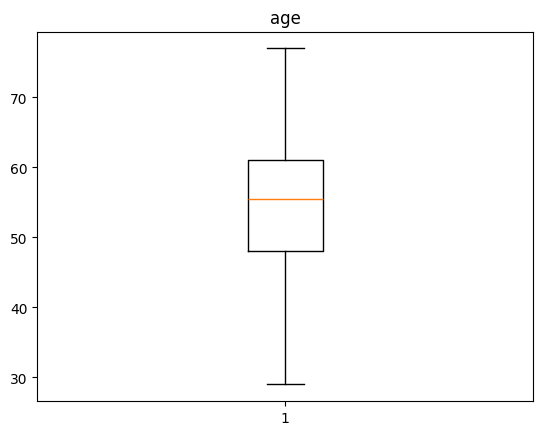

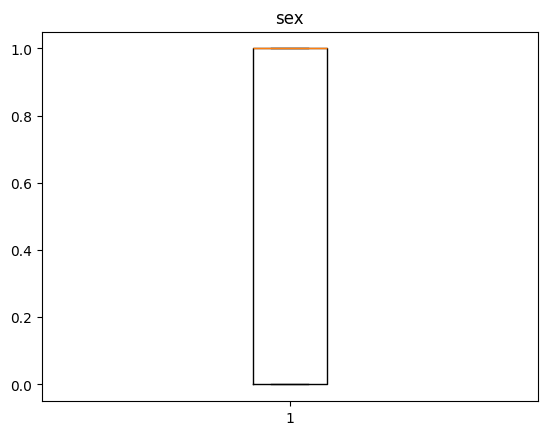

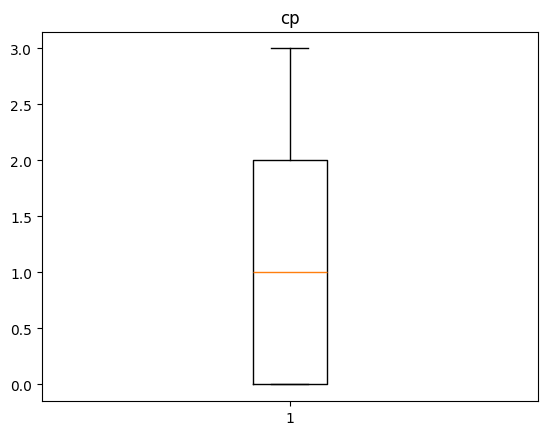

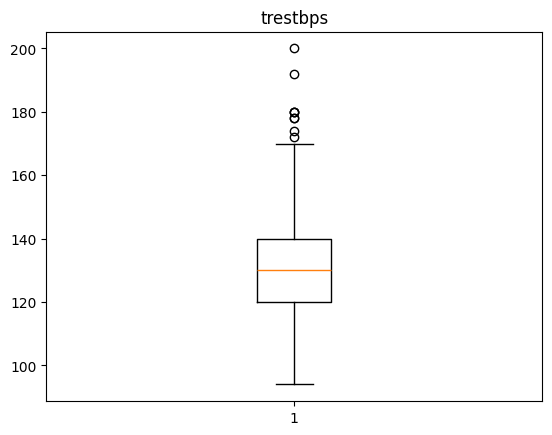

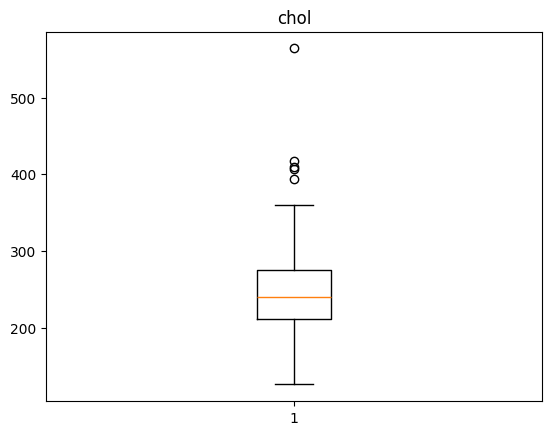

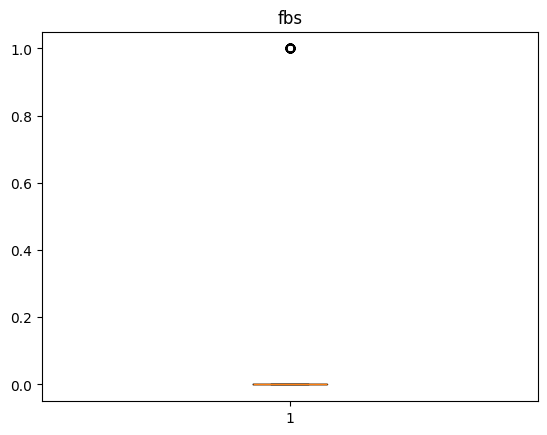

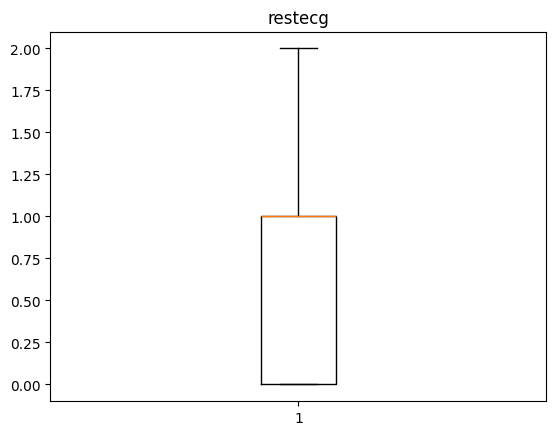

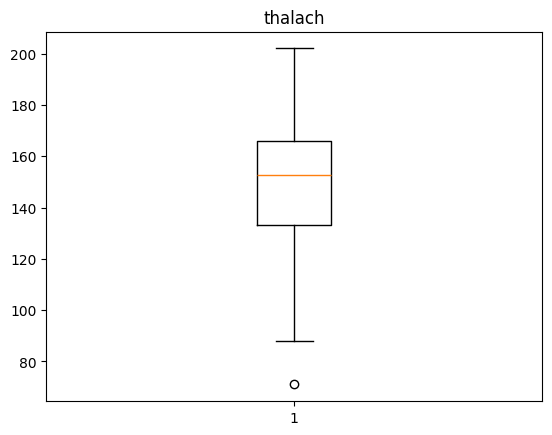

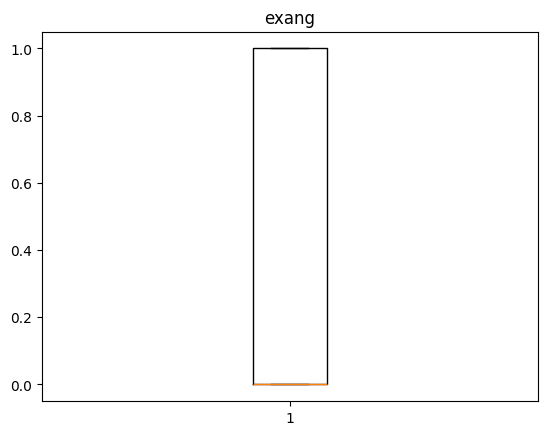

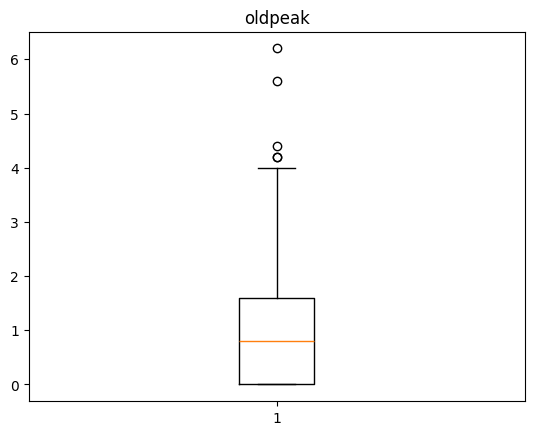

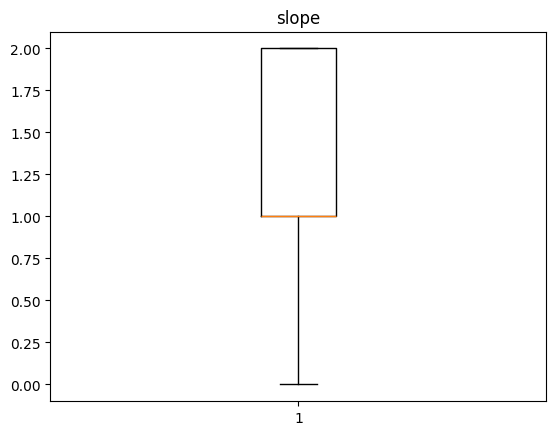

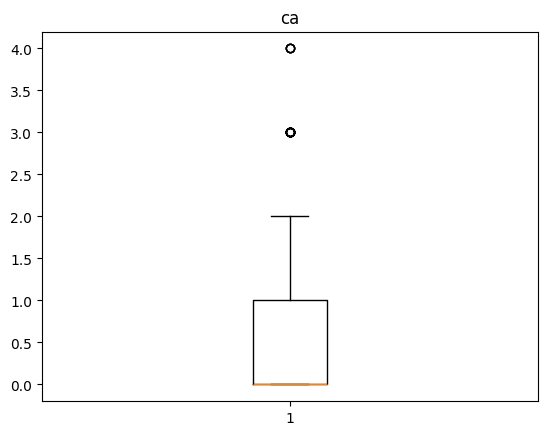

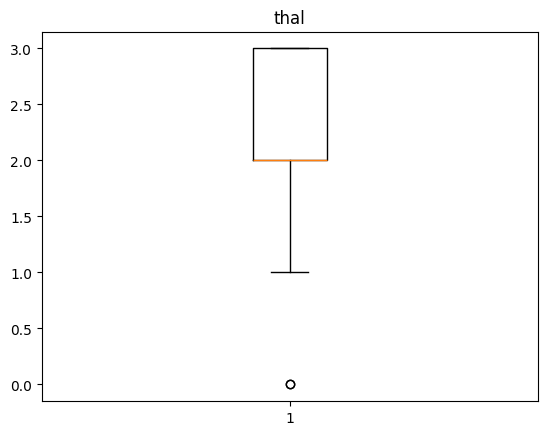

In [59]:
for col in df.columns:
  if(col != 'target'):
    plt.boxplot(df[col])
    plt.title(col)
    plt.show()

no specific outlier --> all are valid
## Model Building

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report

In [61]:
x = df.drop('target', axis = 1)
y = df['target']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

model = DecisionTreeClassifier(random_state = 42, criterion='gini')
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print("Predicted Values:", y_pred)
print("Actual Values:", y_test.values)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Predicted Values: [0 0 1 1 1 1 1 0 0 0 1 0 1 0 1 1 1 0 0 0 0 0 1 1 0 1 0 1 0 1 0 0 0 0 1 0 0
 1 1 1 1 0 1 0 1 0 1 1 0 0 0 0 1 0 0 0 0 1 0 0 0]
Actual Values: [0 0 1 0 1 1 1 0 0 1 1 1 1 0 1 1 1 0 0 0 1 0 0 1 1 0 0 1 0 1 1 0 0 1 1 0 1
 1 1 1 1 1 1 1 1 0 0 1 0 0 0 0 1 1 0 0 0 1 0 0 0]
[[25  4]
 [10 22]]
              precision    recall  f1-score   support

           0       0.71      0.86      0.78        29
           1       0.85      0.69      0.76        32

    accuracy                           0.77        61
   macro avg       0.78      0.77      0.77        61
weighted avg       0.78      0.77      0.77        61



In [62]:
# Showcase Important Features
importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": model.feature_importances_
})

print(importance.sort_values(by="Importance", ascending=False))

     Feature  Importance
12      thal    0.245595
9    oldpeak    0.124155
11        ca    0.120053
0        age    0.113676
4       chol    0.098344
3   trestbps    0.066086
10     slope    0.061857
7    thalach    0.053910
2         cp    0.052818
1        sex    0.045081
5        fbs    0.018425
8      exang    0.000000
6    restecg    0.000000


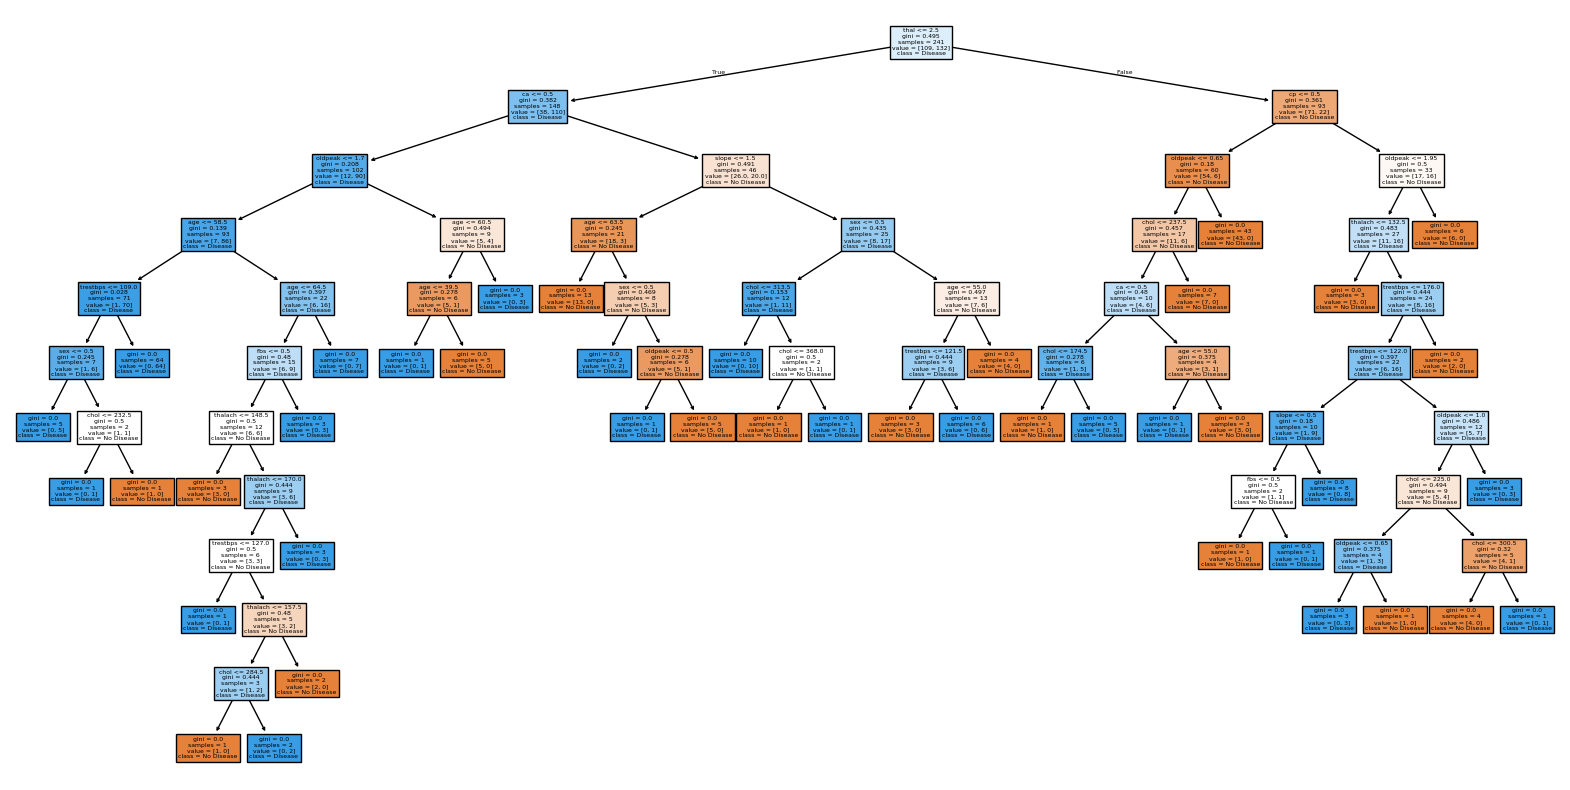

In [63]:
# Visualize the Decision Tree
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    model,
    feature_names=x.columns,
    class_names=["No Disease", "Disease"],
    filled=True
)
plt.show()